#ML Model that predicts if a person is suffereigng from heart diease or not

#### First of all, we import the necessary libraries

In [3]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


# Importing different models to compare their accuracy scores
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

####Now we read the data from our csv file

In [18]:
data=pd.read_csv('/content/Heart_Disease_Prediction.csv')

In [19]:
data.head() #top 5 rows

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [20]:
data.shape

(270, 14)

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

#### From this data information table, we knoe there is no empty cells in our dataset.

### Data Processing

In [9]:
X=data.drop("Heart Disease",axis=1)
y=data["Heart Disease"]




#One hot encoding
cat_cols = ['Chest pain type','EKG results','Slope of ST','Number of vessels fluro','Thallium']
encoder=OneHotEncoder(drop="first", sparse_output=False)

X_encoded=pd.DataFrame(encoder.fit_transform(X[cat_cols]),columns=encoder.get_feature_names_out(cat_cols))

#Drop original categorical columns and add encoded
X=X.drop(cat_cols,axis=1)
X=pd.concat([X.reset_index(drop=True),X_encoded.reset_index(drop=True)],axis=1)


scaler=StandardScaler()
X=scaler.fit_transform(X)

#####Here we have done one hot encoding for the categorical columns so that they convert into binary values. Standard Scaler scales all the data into a specific range.

In [10]:
#Splitting the data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


##### We are using multiple ml models to train the data so that we can compare their accuracy score and choose the best one for building this model.

##1. Logistic Regression model

In [31]:
model=LogisticRegression(max_iter=1000, C=1.0,penalty='l2',)
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [32]:
#predict
y_pred_lr=model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9074074074074074
              precision    recall  f1-score   support

     Absence       0.89      0.97      0.93        33
    Presence       0.94      0.81      0.87        21

    accuracy                           0.91        54
   macro avg       0.92      0.89      0.90        54
weighted avg       0.91      0.91      0.91        54



##2. Decision Tree


In [24]:
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6851851851851852
              precision    recall  f1-score   support

     Absence       0.70      0.85      0.77        33
    Presence       0.64      0.43      0.51        21

    accuracy                           0.69        54
   macro avg       0.67      0.64      0.64        54
weighted avg       0.68      0.69      0.67        54



##3. K-Nearest Neighbors


In [41]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8518518518518519
              precision    recall  f1-score   support

     Absence       0.84      0.94      0.89        33
    Presence       0.88      0.71      0.79        21

    accuracy                           0.85        54
   macro avg       0.86      0.83      0.84        54
weighted avg       0.86      0.85      0.85        54



##4. Support Vector Machine (SVM)

In [34]:
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9074074074074074
              precision    recall  f1-score   support

     Absence       0.91      0.94      0.93        33
    Presence       0.90      0.86      0.88        21

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54



####A Plot to compare the accuracy scores from each models

In [43]:

accuracy_scores = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "SVM": accuracy_score(y_test, y_pred_svm)
}

In [44]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": list(accuracy_scores.keys()),
    "Accuracy": list(accuracy_scores.values())
})

# Sort by accuracy (optional, for nicer plot)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

/tmp/ipython-input-1548870588.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy", y="Model", data=results_df, palette="viridis")


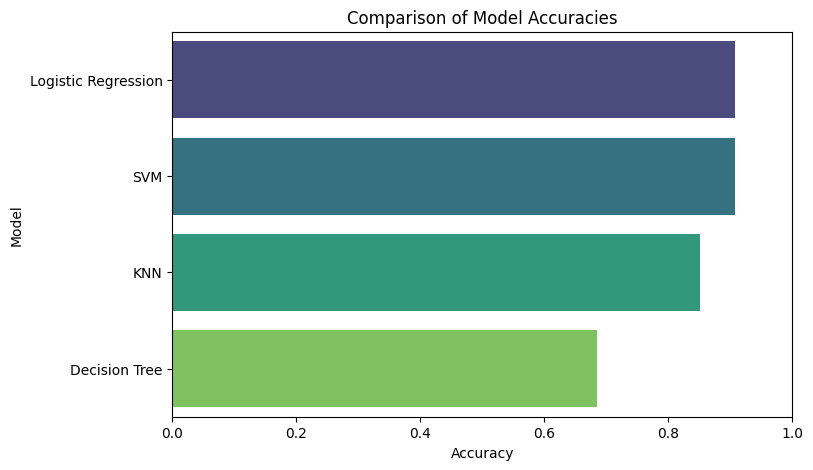

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x="Accuracy", y="Model", data=results_df, palette="viridis")
plt.title("Comparison of Model Accuracies")
plt.xlim(0, 1)  # since accuracy ranges from 0 to 1
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.show()

#####Here we can visualize that using Logistic regression and SVM has given us a good accurate model. So for this project, we are going to take the Logistic regression model

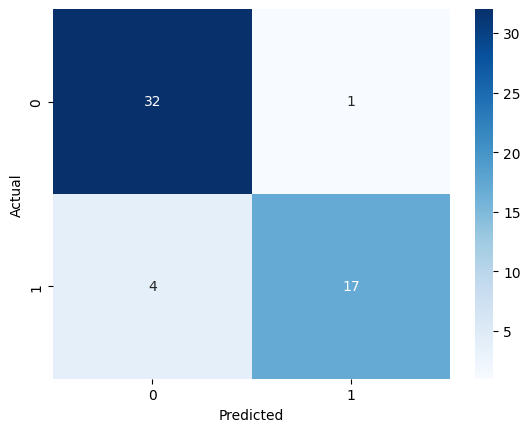

In [46]:
#Confusion Matrix for logistic regression
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

###Saving and loading our model

In [48]:
!pip install joblib


In [49]:
import joblib
joblib.dump(model,'heart_disease.pkl')

#save scaler and encoder
joblib.dump(scaler,'scaler.pkl')
joblib.dump(encoder,'encoder.pkl')

#DOwnloading files to the system (Colab)
from google.colab import files
files.download('heart_disease.pkl')
files.download('scaler.pkl')
files.download('encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
files.download('scaler.pkl')
files.download('encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [58]:
new_data = pd.DataFrame({
    'Chest pain type': [4],  # use number, not "typical angina"
    'EKG results': [0],
    'Slope of ST': [2],
    'Number of vessels fluro': [1],
    'Thallium': [6],
    'Age': [55],
    'Sex': [1],
    'BP': [140],
    'Cholesterol': [250],
    'FBS over 120': [0],
    'Max HR': [150],
    'Exercise angina': [0],
    'ST depression': [1.2]
})

In [59]:
# Transform categorical columns to 0/1
categorical_cols = ['Chest pain type','EKG results','Slope of ST','Number of vessels fluro','Thallium']
encoded_cols = encoder.transform(new_data[categorical_cols])

# Convert to DataFrame
encoded_df = pd.DataFrame(encoded_cols, columns=encoder.get_feature_names_out(categorical_cols))

# Drop original categorical columns and concatenate encoded columns
new_data_final = new_data.drop(columns=categorical_cols).reset_index(drop=True)
new_data_final = pd.concat([new_data_final, encoded_df], axis=1)

print(new_data_final)

   Age  Sex   BP  Cholesterol  FBS over 120  Max HR  Exercise angina  \
0   55    1  140          250             0     150                0   

   ST depression  Chest pain type_2  Chest pain type_3  Chest pain type_4  \
0            1.2                0.0                0.0                1.0   

   EKG results_1  EKG results_2  Slope of ST_2  Slope of ST_3  \
0            0.0            0.0            1.0            0.0   

   Number of vessels fluro_1  Number of vessels fluro_2  \
0                        1.0                        0.0   

   Number of vessels fluro_3  Thallium_6  Thallium_7  
0                        0.0         1.0         0.0  


In [60]:
# model is your trained classifier
predicted_value = model.predict(new_data_final)

print("Predicted value:", predicted_value[0])

Predicted value: Presence


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
